# Necessary dependencies

In [1]:
import numpy as np
import arviz as az
from arviz import stats
import pandas as pd
import pymc as pm
import matplotlib.pyplot as plt

# Exercise

## 1) Loading the dataset into a pandas dataframe

Text(0, 0.5, 'bike rentals')

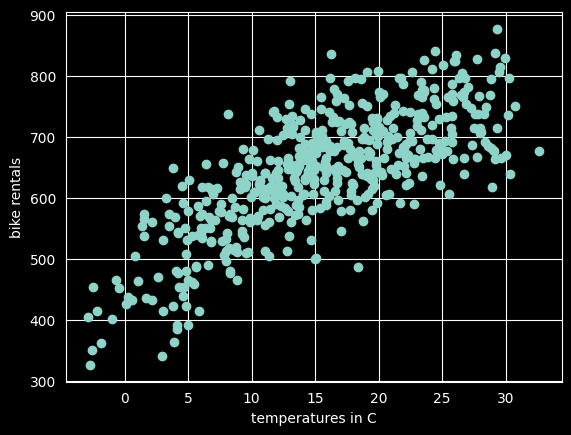

In [3]:
data = pd.read_csv("./bike_daily.csv")

temp_c = data["temp_c"].values
rentals = data["rentals"].values
humidity = data["humidity"].values
wind_kph = data["wind_kph"].values
is_holiday = data["is_holiday"].values
season = data["season"].values

plt.scatter(temp_c, rentals)
plt.xlabel('temperatures in C')
plt.ylabel('bike rentals')

## 2) Rental as a function of temp_c, humidity, wind_kph, is_holiday, season

### a) Standardizing continuous predictions: (temp_c, humidity, wind_kph) and target rentals

$$\theta \sim \sigma(\alpha + \beta_1 temp_c + \beta_2 humidity + \beta_3 wind_kph)$$
$$rentals \sim \mathcal{N}(\theta)$$

### b) The Bayesian Logistical Regression of rentals

In [5]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))


In [21]:
with pm.Model() as rental_model:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta1 = pm.Normal("beta1", mu=0, sigma=10)
    beta2 = pm.Normal("beta2", mu=0, sigma=10)
    beta3 = pm.Normal("beta3", mu=0, sigma=10)

    #likelihood

    theta = sigmoid(alpha + beta1 * temp_c + beta2 * humidity + beta3 * wind_kph)
    rentals_obs = pm.Normal("rentals_obs", mu=theta, sigma=1, observed=rentals)

    idata_rentals = pm.sample(2000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta1, beta2, beta3]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 17 seconds.
There were 3780 divergences after tuning. Increase `target_accept` or reparameterize.


### c) Polynomial regression adding a `temp_c**2` term

In [22]:
temp_c2 = temp_c**2

In [23]:
with pm.Model() as rental_model_pol:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta1 = pm.Normal("beta1", mu=0, sigma=10)
    beta2 = pm.Normal("beta2", mu=0, sigma=10)
    beta3 = pm.Normal("beta3", mu=0, sigma=10)
    beta4 = pm.Normal("beta4", mu=0, sigma=10)

    theta = sigmoid(alpha + beta1 * temp_c + beta2 * humidity + beta3 * wind_kph + beta4 * temp_c2)
    rentals_obs_pol = pm.Normal("rentals_obs_pol", mu=theta, sigma=1, observed=rentals)

    idata_rentals_pol = pm.sample(2000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta1, beta2, beta3, beta4]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 14 seconds.
There were 4863 divergences after tuning. Increase `target_accept` or reparameterize.


## 4) Inferencing and Diagnosis

Using `pm.sample()` sumarizing the posteriors and check which influences the results: Draws, Chains, target_accpts?

The above models were done with `draws=2000`

In [24]:
az.summary(idata_rentals)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,2.221,9.282,-15.443,19.780,0.234,0.157,1570.0,1963.0,1.0
beta1,7.650,5.329,-0.295,17.328,0.159,0.126,1157.0,1720.0,1.0
beta2,1.698,9.757,-16.615,20.102,0.250,0.159,1519.0,1998.0,1.0
beta3,9.797,5.725,0.949,20.688,0.184,0.135,968.0,1563.0,1.0


In [25]:
az.summary(idata_rentals_pol)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.888,9.614,-16.705,19.650,0.242,0.149,1581.0,2006.0,1.0
beta1,1.343,9.369,-15.708,19.222,0.237,0.147,1558.0,2170.0,1.0
beta2,0.329,10.050,-18.309,19.661,0.246,0.179,1670.0,2105.0,1.0
beta3,9.018,6.084,0.173,19.993,0.207,0.150,886.0,1223.0,1.0
beta4,8.672,5.851,-0.237,19.003,0.180,0.109,1020.0,2097.0,1.0


Modifying sampling with `chains=4`

In [26]:
with pm.Model() as rental_model:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta1 = pm.Normal("beta1", mu=0, sigma=10)
    beta2 = pm.Normal("beta2", mu=0, sigma=10)
    beta3 = pm.Normal("beta3", mu=0, sigma=10)

    #likelihood

    theta = sigmoid(alpha + beta1 * temp_c + beta2 * humidity + beta3 * wind_kph)
    rentals_obs = pm.Normal("rentals_obs", mu=theta, sigma=1, observed=rentals)

    idata_rentals = pm.sample(2000, return_inferencedata=True, chains=4)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta1, beta2, beta3]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 17 seconds.
There were 4017 divergences after tuning. Increase `target_accept` or reparameterize.


In [27]:
with pm.Model() as rental_model_pol:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta1 = pm.Normal("beta1", mu=0, sigma=10)
    beta2 = pm.Normal("beta2", mu=0, sigma=10)
    beta3 = pm.Normal("beta3", mu=0, sigma=10)
    beta4 = pm.Normal("beta4", mu=0, sigma=10)

    theta = sigmoid(alpha + beta1 * temp_c + beta2 * humidity + beta3 * wind_kph + beta4 * temp_c2)
    rentals_obs_pol = pm.Normal("rentals_obs_pol", mu=theta, sigma=1, observed=rentals)

    idata_rentals_pol = pm.sample(2000, return_inferencedata=True, chains=4)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta1, beta2, beta3, beta4]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 16 seconds.
There were 5006 divergences after tuning. Increase `target_accept` or reparameterize.


Sumarizing

In [28]:
az.summary(idata_rentals)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,2.405,9.487,-14.955,20.727,0.283,0.157,1122.0,1822.0,1.00
beta1,8.261,5.653,-0.155,18.628,0.187,0.119,956.0,1685.0,1.00
beta2,1.021,9.870,-16.642,20.500,0.257,0.183,1482.0,1566.0,1.00
beta3,9.979,5.840,0.716,21.105,0.179,0.122,1029.0,1673.0,1.01


In [29]:
az.summary(idata_rentals_pol)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,0.739,10.007,-18.371,18.893,0.258,0.170,1515.0,2129.0,1.0
beta1,1.182,9.169,-16.262,18.055,0.276,0.157,1104.0,1973.0,1.0
beta2,0.769,10.068,-18.544,18.997,0.273,0.178,1362.0,2139.0,1.0
beta3,8.750,5.765,0.152,19.331,0.188,0.131,985.0,1627.0,1.0
beta4,8.678,5.975,-0.160,19.295,0.190,0.143,976.0,1601.0,1.0


With `target_accept=0.95`

In [30]:
with pm.Model() as rental_model:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta1 = pm.Normal("beta1", mu=0, sigma=10)
    beta2 = pm.Normal("beta2", mu=0, sigma=10)
    beta3 = pm.Normal("beta3", mu=0, sigma=10)

    #likelihood

    theta = sigmoid(alpha + beta1 * temp_c + beta2 * humidity + beta3 * wind_kph)
    rentals_obs = pm.Normal("rentals_obs", mu=theta, sigma=1, observed=rentals)

    idata_rentals = pm.sample(2000, return_inferencedata=True, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta1, beta2, beta3]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 30 seconds.
There were 493 divergences after tuning. Increase `target_accept` or reparameterize.


In [31]:
with pm.Model() as rental_model_pol:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta1 = pm.Normal("beta1", mu=0, sigma=10)
    beta2 = pm.Normal("beta2", mu=0, sigma=10)
    beta3 = pm.Normal("beta3", mu=0, sigma=10)
    beta4 = pm.Normal("beta4", mu=0, sigma=10)

    theta = sigmoid(alpha + beta1 * temp_c + beta2 * humidity + beta3 * wind_kph + beta4 * temp_c2)
    rentals_obs_pol = pm.Normal("rentals_obs_pol", mu=theta, sigma=1, observed=rentals)

    idata_rentals_pol = pm.sample(2000, return_inferencedata=True, target_accept=0.95)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta1, beta2, beta3, beta4]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 42 seconds.
There were 2084 divergences after tuning. Increase `target_accept` or reparameterize.


Sumarize

In [32]:
az.summary(idata_rentals)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,2.554,9.615,-15.531,19.914,0.191,0.148,2539.0,2965.0,1.0
beta1,8.055,5.562,-0.132,18.269,0.164,0.134,1253.0,1553.0,1.0
beta2,1.730,9.802,-16.071,20.407,0.184,0.139,2842.0,3208.0,1.0
beta3,10.003,6.031,0.463,21.041,0.172,0.132,1347.0,2052.0,1.0


In [33]:
az.summary(idata_rentals_pol)

,mean,sd,hdi_3%,hdi_97%,mcse_mean,mcse_sd,ess_bulk,ess_tail,r_hat
alpha,1.012,9.916,-17.064,20.172,0.187,0.137,2795.0,3342.0,1.0
beta1,1.055,9.313,-16.645,18.079,0.179,0.127,2721.0,3260.0,1.0
beta2,0.480,9.976,-17.943,19.424,0.183,0.133,2984.0,3749.0,1.0
beta3,8.922,5.932,0.152,19.985,0.158,0.121,1503.0,2110.0,1.0
beta4,8.800,6.163,-0.173,19.994,0.166,0.130,1401.0,2095.0,1.0


Out of all variables the one that influences the most is `temp_c`

## 4) Model Comparison and PPC

### a) Compare both model's WAIC or LOOCV: Why?

Computing both model's WAIC

In [35]:
pm.compute_log_likelihood(idata_rentals, model=rental_model)
az.waic(idata_rentals)

Output()

Computed from 8000 posterior samples and 500 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -105169428.50  1352847.31
p_waic        0.02        -

In [37]:
pm.compute_log_likelihood(idata_rentals_pol, model=rental_model_pol)
az.waic(idata_rentals_pol)

Output()

Computed from 8000 posterior samples and 500 observations log-likelihood matrix.

          Estimate       SE
elpd_waic -105169428.49  1352847.31
p_waic        0.01        -

### b) Perform Posterior checks, visualize predicted mean and uncertainty vs `temp_c`

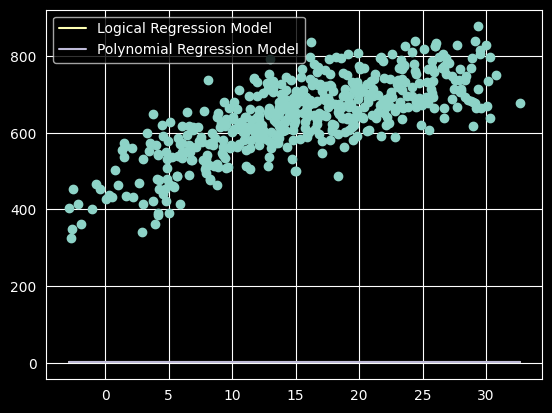

In [53]:
new_temp_c=np.linspace(temp_c.min(), temp_c.max(), 500)

alpha_l_post = idata_rentals.posterior["alpha"].mean(("chain", "draw")).values
beta1_l_post = idata_rentals.posterior["beta1"].mean(("chain", "draw")).values
beta2_l_post = idata_rentals.posterior["beta2"].mean(("chain", "draw")).values
beta3_l_post = idata_rentals.posterior["beta3"].mean(("chain", "draw")).values

obs_l_post = sigmoid(alpha_l_post + beta1_l_post * temp_c + beta2_l_post * humidity + beta3_l_post * wind_kph)

plt.plot(new_temp_c, obs_l_post, 'C1', label="Logical Regression Model")


alpha_p_post = idata_rentals_pol.posterior["alpha"].mean(("chain", "draw")).values
beta1_p_post = idata_rentals_pol.posterior["beta1"].mean(("chain", "draw")).values
beta2_p_post = idata_rentals_pol.posterior["beta2"].mean(("chain", "draw")).values
beta3_p_post = idata_rentals_pol.posterior["beta3"].mean(("chain", "draw")).values
beta4_p_post = idata_rentals_pol.posterior["beta4"].mean(("chain", "draw")).values

obs_p_post = sigmoid(alpha_p_post + beta1_p_post * temp_c + beta2_p_post * humidity + beta3_p_post * wind_kph + beta4_p_post * temp_c2)

plt.plot(new_temp_c, obs_p_post, 'C2', label="Polynomial Regression Model")

plt.scatter(temp_c, rentals)
plt.legend()

## 5) Construct the `is_high_demand` variable as follows:

$$is\_high\_demand=\begin{cases}
    1\ if\ rentals \ge Q\\
    0\ otherwise
\end{cases}$$

where $Q$ is the 75th percentile of rentals

In [39]:
Q = rentals[75]
is_high_demand = np.where(rentals >= Q, 1, 0)

## 6) Bayesian Logic Regression Model with `is_high_demand`

In [40]:
with pm.Model() as rental_model_new:
    alpha = pm.Normal("alpha", mu=0, sigma=10)
    beta1 = pm.Normal("beta1", mu=0, sigma=10)
    beta2 = pm.Normal("beta2", mu=0, sigma=10)
    beta3 = pm.Normal("beta3", mu=0, sigma=10)
    beta4 = pm.Normal("beta4", mu=0, sigma=10)

    theta = sigmoid(alpha + beta1 * temp_c + beta2 * humidity + beta3 * wind_kph + beta4 * is_high_demand)
    rentals_obs_new = pm.Normal("rentals_obs_new", mu=theta, sigma=1, observed=rentals)

    idata_rentals_new = pm.sample(2000, return_inferencedata=True)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [alpha, beta1, beta2, beta3, beta4]


Output()

Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 13 seconds.
There were 3929 divergences after tuning. Increase `target_accept` or reparameterize.


## 7) Obtain 95% HDI for each parameter

In [44]:
az.hdi(idata_rentals_new, hdi_prob=0.95)

<xarray.Dataset> Size: 128B
Dimensions:  (hdi: 2)
Coordinates:
  * hdi      (hdi) <U6 48B 'lower' 'higher'
Data variables:
    alpha    (hdi) float64 16B -16.99 21.73
    beta1    (hdi) float64 16B -0.2374 17.73
    beta2    (hdi) float64 16B -18.74 20.47
    beta3    (hdi) float64 16B 0.7646 21.87
    beta4    (hdi) float64 16B -18.33 22.11
Attributes:
    created_at:                 2026-01-26T09:00:00.768555+00:00
    arviz_version:              0.23.0
    inference_library:          pymc
    inference_library_version:  5.27.0
    sampling_time:              13.356716871261597
    tuning_steps:               1000

The value I believe influences the the outcome is the `temp_c`